# Iterative Magnitude Pruning on SSM (Mamba) - Mackey-Glass Forecasting

**Goal**: Find the maximum sparsity threshold a Mamba SSM can tolerate before
its continuous-time dynamics lose predictive power on a chaotic time-series task.

**Runtime**: This notebook requires a GPU (Colab T4 or better).  

## 0. Install mamba + torch

In [1]:
!pip install torch==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install causal-conv1d==1.4.0 && pip install mamba-ssm==2.2.2 --no-build-isolation


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 1.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 82.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 120.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Make the project importable

In [2]:
import os, sys, importlib

def _pkg_available() -> bool:
    try:
        importlib.import_module("magnitude_pruning")
        return True
    except ModuleNotFoundError:
        return False

#  Local runtime (VS Code + Colab extension with local kernel
# The package lives inside ssm_magnitude_pruning/, so we add that folder.
LOCAL_CANDIDATES = [
    # Colab cloud path after cloning
    "/content/ssm-orp/ssm_magnitude_pruning",
    # Common local paths (adjust if your repo is elsewhere)
    os.path.expanduser("~/ssm-orp/ssm_magnitude_pruning"),
    # Relative to notebook location (works when kernel CWD = ssm_magnitude_pruning/)
    os.path.abspath("."),
]

for path in LOCAL_CANDIDATES:
    if os.path.isdir(os.path.join(path, "magnitude_pruning")):
        if path not in sys.path:
            sys.path.insert(0, path)
        print(f"Using local repo at: {path}")
        break

# Cloud Colab: clone if still not importable
if not _pkg_available():
    REPO_URL = "https://github.com/gre1wy/ssm-orp"
    BRANCH   = "feat/ssm-magnitude-pruning"
    REPO_DIR = "/content/ssm-orp"
    if not os.path.exists(REPO_DIR):
        os.system(f"git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}")
    else:
        os.system(f"git -C {REPO_DIR} pull")
    pkg_dir = f"{REPO_DIR}/ssm_magnitude_pruning"
    if pkg_dir not in sys.path:
        sys.path.insert(0, pkg_dir)
    print(f"Cloned repo to: {REPO_DIR}")

print("magnitude_pruning importable:", _pkg_available())

Cloned repo to: /content/ssm-orp
magnitude_pruning importable: True


## 2. Imports|

In [3]:
# mamba-ssm 2.2.2 references classes removed in transformers >= 4.40.
# We stub them out so the import succeeds; they are never called in our code.
import transformers.generation as _tg
for _name in ("GreedySearchDecoderOnlyOutput", "SampleDecoderOnlyOutput", "TextStreamer"):
    if not hasattr(_tg, _name):
        setattr(_tg, _name, type(_name, (), {}))


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from magnitude_pruning.dataset       import mackey_glass, build_loaders, inject_anomalies
from magnitude_pruning.model         import MambaForecaster
from magnitude_pruning.pruning       import sparsity_schedule, get_sparsity
from magnitude_pruning.experiment    import ExperimentConfig, run_experiment
from magnitude_pruning.visualization import (
    plot_training_curves,
    plot_sparsity_vs_mse,
    plot_robustness_degradation,
    plot_dashboard,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: mamba-ssm requires CUDA.  Switch to a GPU runtime.")

/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/dis

Using device: cuda


## 3. Inspect the Mackey-Glass dataset

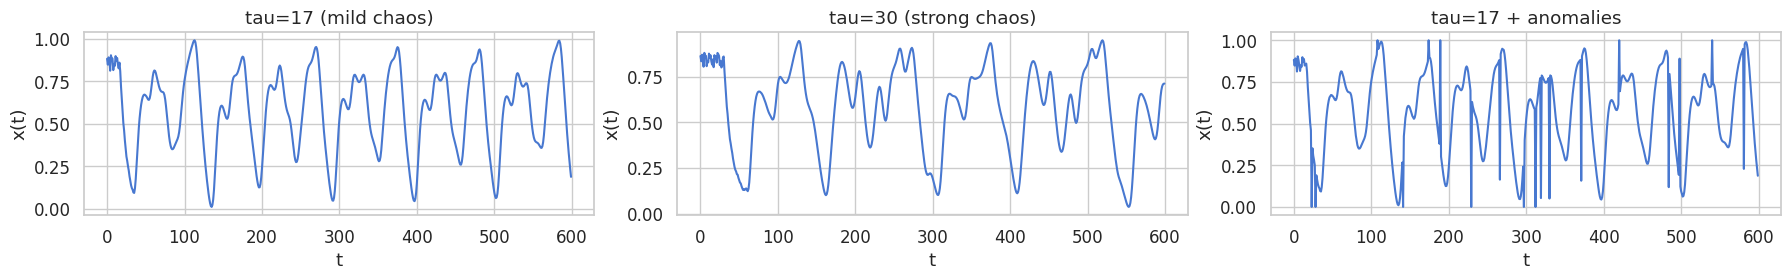

In [5]:
series_mild   = mackey_glass(n_steps=3000, tau=17, seed=42)   # mildly chaotic
series_strong = mackey_glass(n_steps=3000, tau=30, seed=42)   # strongly chaotic
series_anom   = inject_anomalies(series_mild, missing_frac=0.05,
                                  spike_frac=0.03, spike_magnitude=3.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 3))
for ax, s, title in zip(
    axes,
    [series_mild, series_strong, series_anom],
    ["tau=17 (mild chaos)", "tau=30 (strong chaos)", "tau=17 + anomalies"],
):
    ax.plot(s[:600])
    ax.set_title(title)
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")
plt.tight_layout()
plt.savefig("mackey_glass_series.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Quick single-seed experiment

Runs one seed with a reduced model and fewer epochs.  
Skip this cell and go directly to **Section 5** for the full experiment.

In [6]:
quick_cfg = ExperimentConfig(
    d_model=32, d_state=8, n_layers=2,          # smaller model
    n_epochs=10, finetune_epochs=3,              # fewer epochs
    seeds=[42],                                  # single seed
    n_sparsity_steps=8,
    sparsity_end=0.95,
    device=device,
)

quick_results = run_experiment(quick_cfg, verbose=True)
print("\nBreaking point (quick run):", quick_results["breaking_points"])

[seed=42] Model parameters: 16,897
[seed=42] Training dense baseline …


Training:   0%|          | 0/10 [00:00<?, ?it/s]

  [seed=42] Pruning to sparsity 0.00% … actual=0.01%  val_mse=0.00003
  [seed=42] Pruning to sparsity 35.17% … actual=32.17%  val_mse=0.00004
  [seed=42] Pruning to sparsity 60.38% … actual=55.23%  val_mse=0.00007
  [seed=42] Pruning to sparsity 77.27% … actual=70.68%  val_mse=0.00115
  [seed=42] Pruning to sparsity 87.52% … actual=80.06%  val_mse=0.01215
  [seed=42] Pruning to sparsity 92.78% … actual=84.87%  val_mse=0.20446
  [seed=42] Pruning to sparsity 94.72% … actual=86.64%  val_mse=0.21887
  [seed=42] Pruning to sparsity 95.00% … actual=86.90%  val_mse=0.21915

Breaking point (quick run): [0.7068118600935077]


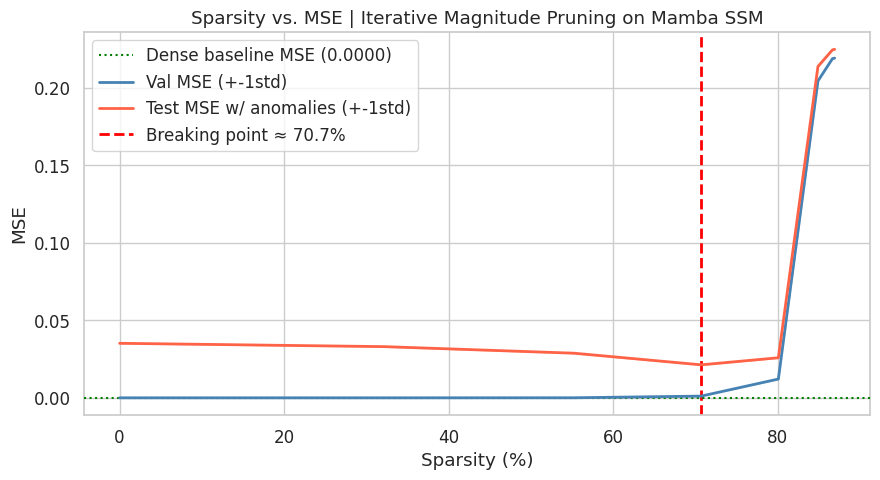

In [7]:
fig = plot_sparsity_vs_mse(quick_results)
plt.savefig("quick_sparsity_vs_mse.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Full experiment (10 seeds)

Runs the complete IMP study with 10 random seeds to obtain confidence intervals.

In [8]:
full_cfg = ExperimentConfig(
    d_model=64, d_state=16, d_conv=4, expand=2, n_layers=4,
    horizon=1,
    seq_len=128,
    n_total=12_000,
    batch_size=64,
    tau=17,                         
    n_epochs=30,
    lr=1e-3,
    patience=7,
    finetune_epochs=5,
    finetune_lr=3e-4,
    sparsity_start=0.0,
    sparsity_end=0.99,
    n_sparsity_steps=14,
    log_scale_schedule=True,
    seeds=[42, 7, 123, 3, 8, 9, 91, 56, 71, 55],
    breaking_factor = 5.0,
    breaking_floor = 1e-3,
    device=device,
)

full_results = run_experiment(full_cfg, verbose=True)

[seed=42] Model parameters: 130,817
[seed=42] Training dense baseline …


Training:   0%|          | 0/30 [00:00<?, ?it/s]

  [seed=42] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=42] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=42] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=42] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00000
  [seed=42] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00000
  [seed=42] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00005
  [seed=42] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00004
  [seed=42] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00420
  [seed=42] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.01854
  [seed=42] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.18979
  [seed=42] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.18977
  [seed=42] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.18980
  [seed=42] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.18978
  [seed=42] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.

Training:   0%|          | 0/30 [00:00<?, ?it/s]

  [seed=7] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=7] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=7] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=7] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00000
  [seed=7] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00001
  [seed=7] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00002
  [seed=7] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00019
  [seed=7] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00371
  [seed=7] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.01076
  [seed=7] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.19721
  [seed=7] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.19720
  [seed=7] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.19736
  [seed=7] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.19729
  [seed=7] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.19725
[seed=12

...

  [seed=56] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=56] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=56] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=56] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00000
  [seed=56] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00001
  [seed=56] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00001
  [seed=56] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00007
  [seed=56] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00043
  [seed=56] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.00214
  [seed=56] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.17416
  [seed=56] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.17380
  [seed=56] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.17383
  [seed=56] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.17392
  [seed=56] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.

Training:   0%|          | 0/30 [00:00<?, ?it/s]

  [seed=71] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=71] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=71] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=71] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00001
  [seed=71] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00003
  [seed=71] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00005
  [seed=71] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00009
  [seed=71] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00057
  [seed=71] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.00700
  [seed=71] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.22832
  [seed=71] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.22820
  [seed=71] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.22830
  [seed=71] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.22831
  [seed=71] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.

Training:   0%|          | 0/30 [00:00<?, ?it/s]

  [seed=55] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=55] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=55] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=55] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00001
  [seed=55] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00003
  [seed=55] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00006
  [seed=55] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00013
  [seed=55] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00118
  [seed=55] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.20029
  [seed=55] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.20024
  [seed=55] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.20018
  [seed=55] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.20024
  [seed=55] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.20010
  [seed=55] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.

## 6. Results & analysis

In [9]:
bps = [b for b in full_results["breaking_points"] if b is not None]
print("=== Breaking Point Analysis ===")
print(f"Breaking points per seed : {full_results['breaking_points']}")
if bps:
    print(f"Median breaking point    : {np.median(bps)*100:.1f}%")
    print(f"Std                      : +-{np.std(bps)*100:.1f}%")
else:
    print("No breaking point reached (model is very robust).")

print("\n=== Baseline Val MSE per seed ===")
for s, b in zip(full_cfg.seeds, full_results["baseline_val_mse"]):
    print(f"  seed={s}: {b:.7f}")

=== Breaking Point Analysis ===
Breaking points per seed : [0.8258712552649885, 0.8258712552649885, 0.8892422238699863, 0.8258712552649885, 0.8638021052309716, 0.8638021052309716, 0.8258712552649885, 0.8638021052309716, 0.8638021052309716, 0.8258712552649885]
Median breaking point    : 84.5%
Std                      : +-2.3%

=== Baseline Val MSE per seed ===
  seed=42: 0.0000021
  seed=7: 0.0000037
  seed=123: 0.0000019
  seed=3: 0.0000046
  seed=8: 0.0000020
  seed=9: 0.0000028
  seed=91: 0.0000033
  seed=56: 0.0000017
  seed=71: 0.0000034
  seed=55: 0.0000035


In [10]:
# Print a summary table
print(f"{'Sparsity':>10} {'Val MSE':>12} {'+-std':>8} {'Anom MSE':>12} {'+-std':>8}")
print("-" * 55)
for i, s in enumerate(full_results["sparsities"]):
    print(
        f"{s*100:>9.1f}%"
        f" {full_results['val_mse_mean'][i]:>12.5f}"
        f" {full_results['val_mse_std'][i]:>8.5f}"
        f" {full_results['test_mse_anomaly_mean'][i]:>12.5f}"
        f" {full_results['test_mse_anomaly_std'][i]:>8.5f}"
    )

  Sparsity      Val MSE    +-std     Anom MSE    +-std
-------------------------------------------------------
      0.0%      0.00000  0.00000      0.14416  0.07030
     19.5%      0.00000  0.00000      0.14079  0.06876
     36.1%      0.00000  0.00000      0.12867  0.05755
     49.9%      0.00001  0.00000      0.10299  0.04618
     61.2%      0.00001  0.00001      0.08397  0.03884
     70.2%      0.00003  0.00002      0.08012  0.05255
     77.3%      0.00012  0.00011      0.05884  0.03562
     82.6%      0.00227  0.00265      0.04671  0.04346
     86.4%      0.05632  0.08039      0.06986  0.07537
     88.9%      0.21608  0.06587      0.22051  0.06344
     90.5%      0.22856  0.04591      0.23265  0.04442
     91.3%      0.22861  0.04589      0.23270  0.04440
     91.5%      0.22859  0.04589      0.23268  0.04440
     91.6%      0.22861  0.04586      0.23269  0.04436


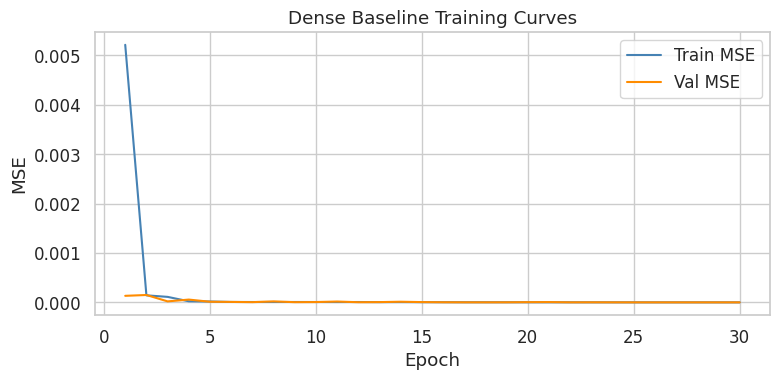

In [11]:
fig = plot_training_curves(full_results, seed_idx=0)
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

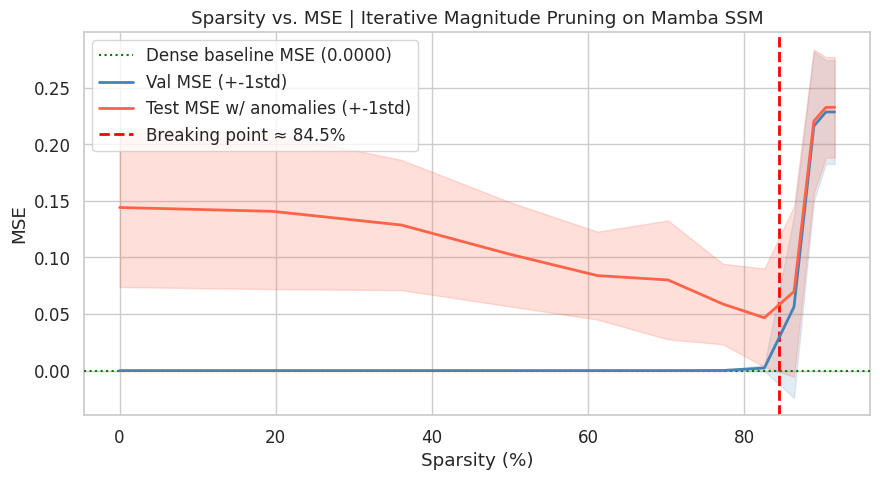

In [12]:
fig = plot_sparsity_vs_mse(full_results, show_anomaly=True)
plt.savefig("sparsity_vs_mse.png", dpi=120, bbox_inches="tight")
plt.show()

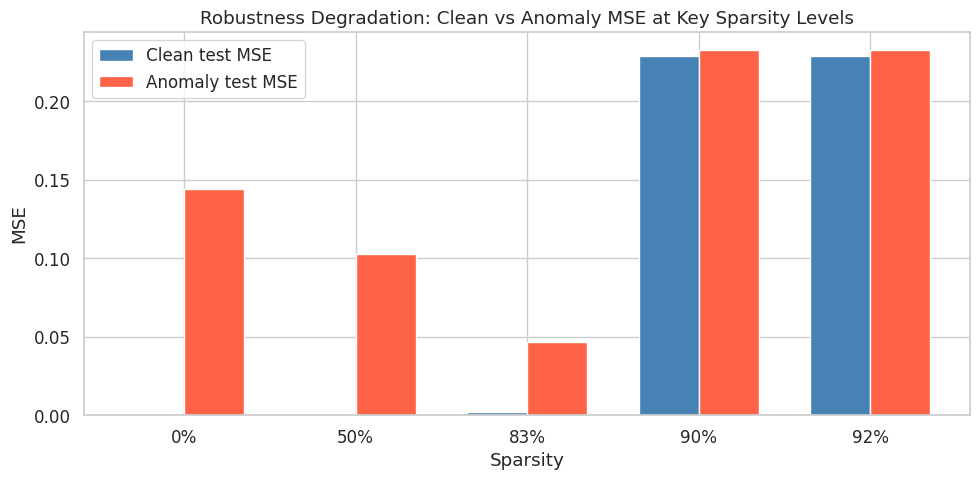

In [13]:
fig = plot_robustness_degradation(
    full_results,
    sparsity_checkpoints=[0.0, 0.5, 0.8, 0.9, 0.95],
)
plt.savefig("robustness_degradation.png", dpi=120, bbox_inches="tight")
plt.show()

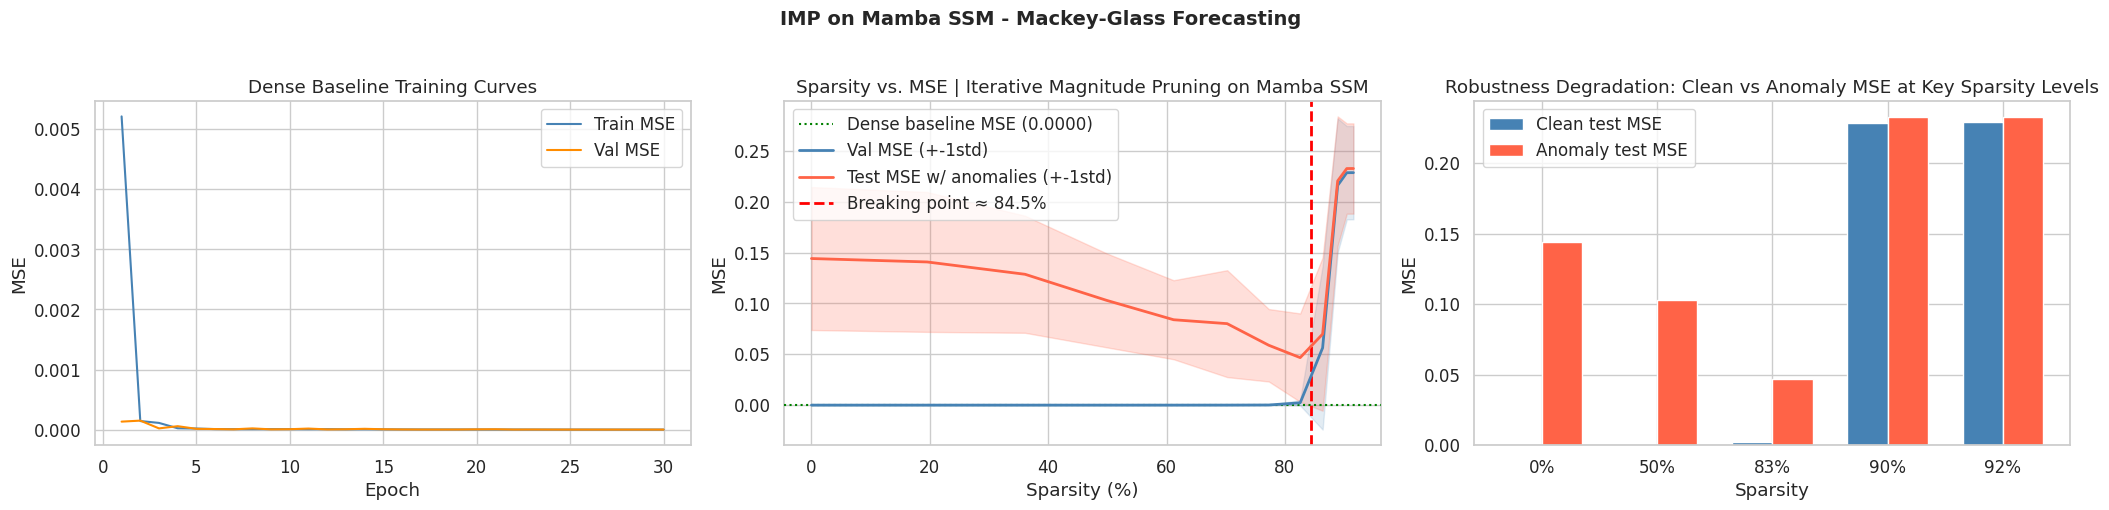

In [14]:
fig = plot_dashboard(full_results)
plt.savefig("dashboard.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Ablation: strong chaos (tau=30)

Repeat the experiment with a more chaotic series to see whether longer-range
dependencies make the model more or less sensitive to sparsity.

In [15]:
ablation_cfg = ExperimentConfig(
    **{k: v for k, v in full_cfg.__dict__.items() if k != "tau"},
    tau=30,   # strongly chaotic regime
)

ablation_results = run_experiment(ablation_cfg, verbose=True)

[seed=42] Model parameters: 130,817
[seed=42] Training dense baseline …


Training:   0%|          | 0/30 [00:00<?, ?it/s]

  [seed=42] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=42] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=42] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=42] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00000
  [seed=42] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00001
  [seed=42] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00003
  [seed=42] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00003
  [seed=42] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00033
  [seed=42] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.02685
  [seed=42] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.19838
  [seed=42] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.19847
  [seed=42] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.19851
  [seed=42] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.19851
  [seed=42] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.

Training:   0%|          | 0/30 [00:00<?, ?it/s]

  [seed=7] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=7] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=7] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=7] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00000
  [seed=7] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00001
  [seed=7] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00004
  [seed=7] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00009
  [seed=7] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00409
  [seed=7] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.02382
  [seed=7] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.20213
  [seed=7] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.20189
  [seed=7] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.20196
  [seed=7] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.20187
  [seed=7] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.20204
[seed=12

...

  [seed=56] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=56] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=56] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=56] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00000
  [seed=56] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00001
  [seed=56] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00002
  [seed=56] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00005
  [seed=56] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00042
  [seed=56] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.00432
  [seed=56] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.18138
  [seed=56] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.18131
  [seed=56] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.18126
  [seed=56] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.18124
  [seed=56] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.

Training:   0%|          | 0/30 [00:00<?, ?it/s]

  [seed=71] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=71] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=71] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00000
  [seed=71] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00001
  [seed=71] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00002
  [seed=71] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00005
  [seed=71] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00010
  [seed=71] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00140
  [seed=71] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.00716
  [seed=71] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.23983
  [seed=71] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.23979
  [seed=71] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.23992
  [seed=71] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.23981
  [seed=71] Pruning to sparsity 99.00% … actual=91.59%  val_mse=0.

Training:   0%|          | 0/30 [00:00<?, ?it/s]

Early stopping at epoch 17
  [seed=55] Pruning to sparsity 0.00% … actual=0.00%  val_mse=0.00000
  [seed=55] Pruning to sparsity 21.13% … actual=19.55%  val_mse=0.00000
  [seed=55] Pruning to sparsity 39.02% … actual=36.10%  val_mse=0.00001
  [seed=55] Pruning to sparsity 53.94% … actual=49.90%  val_mse=0.00001
  [seed=55] Pruning to sparsity 66.15% … actual=61.20%  val_mse=0.00002
  [seed=55] Pruning to sparsity 75.93% … actual=70.25%  val_mse=0.00006
  [seed=55] Pruning to sparsity 83.54% … actual=77.29%  val_mse=0.00048
  [seed=55] Pruning to sparsity 89.27% … actual=82.59%  val_mse=0.00352
  [seed=55] Pruning to sparsity 93.37% … actual=86.38%  val_mse=0.02820
  [seed=55] Pruning to sparsity 96.12% … actual=88.92%  val_mse=0.21745
  [seed=55] Pruning to sparsity 97.78% … actual=90.46%  val_mse=0.21735
  [seed=55] Pruning to sparsity 98.64% … actual=91.26%  val_mse=0.21743
  [seed=55] Pruning to sparsity 98.95% … actual=91.54%  val_mse=0.21735
  [seed=55] Pruning to sparsity 99.00% 

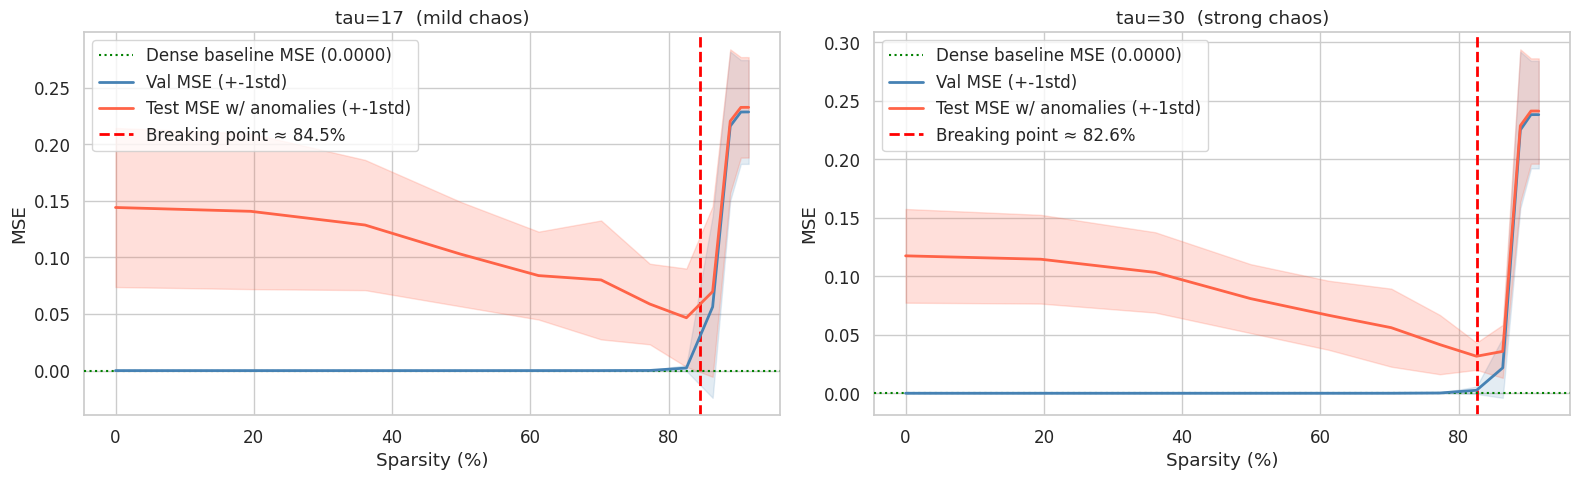

Median breaking point τ=17: 84.5%
Median breaking point τ=30: 82.6%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_sparsity_vs_mse(full_results,    ax=axes[0])
axes[0].set_title("tau=17  (mild chaos)")
plot_sparsity_vs_mse(ablation_results, ax=axes[1])
axes[1].set_title("tau=30  (strong chaos)")
plt.tight_layout()
plt.savefig("ablation_tau.png", dpi=120, bbox_inches="tight")
plt.show()

bp17 = [b for b in full_results["breaking_points"]    if b is not None]
bp30 = [b for b in ablation_results["breaking_points"] if b is not None]
print(f"Median breaking point τ=17: {np.median(bp17)*100:.1f}%" if bp17 else "No BP at τ=17")
print(f"Median breaking point τ=30: {np.median(bp30)*100:.1f}%" if bp30 else "No BP at τ=30")

In [17]:
bps30 = [b for b in ablation_results["breaking_points"] if b is not None]
print("=== Breaking Point Analysis (tau=30) ===")
print(f"Breaking points per seed : {ablation_results['breaking_points']}")
if bps30:
    print(f"Median breaking point    : {np.median(bps30)*100:.1f}%")
    print(f"Std                      : +-{np.std(bps30)*100:.1f}%")
else:
    print("No breaking point reached (model is very robust).")

print("=== Baseline Val MSE per seed ===")
for s, b in zip(ablation_cfg.seeds, ablation_results["baseline_val_mse"]):
    print(f"  seed={s}: {b:.7f}")

=== Breaking Point Analysis (tau=30) ===
Breaking points per seed : [0.8638021052309716, 0.8258712552649885, 0.8892422238699863, 0.8258712552649885, 0.8258712552649885, 0.8638021052309716, 0.8258712552649885, 0.8638021052309716, 0.8258712552649885, 0.8258712552649885]
Median breaking point    : 82.6%
Std                      : +-2.3%
=== Baseline Val MSE per seed ===
  seed=42: 0.0000021
  seed=7: 0.0000028
  seed=123: 0.0000015
  seed=3: 0.0000032
  seed=8: 0.0000022
  seed=9: 0.0000011
  seed=91: 0.0000022
  seed=56: 0.0000011
  seed=71: 0.0000029
  seed=55: 0.0000057


In [18]:
# Summary table for tau=30
print(f"{'Sparsity':>10} {'Val MSE':>12} {'+-std':>8} {'Anom MSE':>12} {'+-std':>8}")
print("-" * 55)
for i, s in enumerate(ablation_results["sparsities"]):
    print(
        f"{s*100:>9.1f}%"
        f" {ablation_results['val_mse_mean'][i]:>12.5f}"
        f" {ablation_results['val_mse_std'][i]:>8.5f}"
        f" {ablation_results['test_mse_anomaly_mean'][i]:>12.5f}"
        f" {ablation_results['test_mse_anomaly_std'][i]:>8.5f}"
    )

  Sparsity      Val MSE    +-std     Anom MSE    +-std
-------------------------------------------------------
      0.0%      0.00000  0.00000      0.11744  0.04005
     19.5%      0.00000  0.00000      0.11455  0.03791
     36.1%      0.00000  0.00000      0.10329  0.03433
     49.9%      0.00001  0.00000      0.08089  0.02944
     61.2%      0.00001  0.00001      0.06663  0.02951
     70.2%      0.00003  0.00002      0.05605  0.03336
     77.3%      0.00022  0.00020      0.04157  0.02533
     82.6%      0.00252  0.00312      0.03162  0.01164
     86.4%      0.02172  0.02564      0.03578  0.02262
     88.9%      0.22503  0.06693      0.22864  0.06528
     90.5%      0.23812  0.04596      0.24121  0.04502
     91.3%      0.23815  0.04596      0.24123  0.04503
     91.5%      0.23810  0.04597      0.24118  0.04504
     91.6%      0.23810  0.04594      0.24118  0.04501


## 8. Run tests

`test_dataset.py` and `test_pruning.py` run on CPU and finish in seconds.  
`test_model.py` runs only when CUDA is available.

In [19]:
# Find the folder that contains our tests/ directory
import pathlib
_here = pathlib.Path(sys.path[0])  # the path we added in cell 1
!pip install --quiet pytest
!python -m pytest {_here}/tests/ -v 2>&1 | tail -40

ssm-orp/ssm_magnitude_pruning/tests/test_pruning.py::test_schedule_length PASSED [ 90%]
ssm-orp/ssm_magnitude_pruning/tests/test_pruning.py::test_schedule_bounds PASSED [ 93%]
ssm-orp/ssm_magnitude_pruning/tests/test_pruning.py::test_schedule_monotone PASSED [ 96%]
ssm-orp/ssm_magnitude_pruning/tests/test_pruning.py::test_log_schedule_has_more_high_end PASSED [100%]

=============================== warnings summary ===============================
../usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163
  /usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
    @custom_fwd

../usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239
  /usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_b

## 9. Save results to disk

In [20]:
import pickle, json

# Save the raw results dict for post-processing
with open("imp_results.pkl", "wb") as f:
    pickle.dump({"full": full_results, "ablation": ablation_results}, f)

# Save a JSON summary
summary = {
    "tau17": {
        "sparsities":          full_results["sparsities"].tolist(),
        "val_mse_mean":         full_results["val_mse_mean"].tolist(),
        "val_mse_std":          full_results["val_mse_std"].tolist(),
        "test_mse_anomaly_mean": full_results["test_mse_anomaly_mean"].tolist(),
        "breaking_points":      full_results["breaking_points"],
        "baseline_val_mse":     full_results["baseline_val_mse"],
    },
    "tau30": {
        "sparsities":          ablation_results["sparsities"].tolist(),
        "val_mse_mean":         ablation_results["val_mse_mean"].tolist(),
        "val_mse_std":          ablation_results["val_mse_std"].tolist(),
        "test_mse_anomaly_mean": ablation_results["test_mse_anomaly_mean"].tolist(),
        "breaking_points":      ablation_results["breaking_points"],
        "baseline_val_mse":     ablation_results["baseline_val_mse"],
    },
}
with open("imp_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved imp_results.pkl and imp_summary.json")

Saved imp_results.pkl and imp_summary.json
